In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 


In [2]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


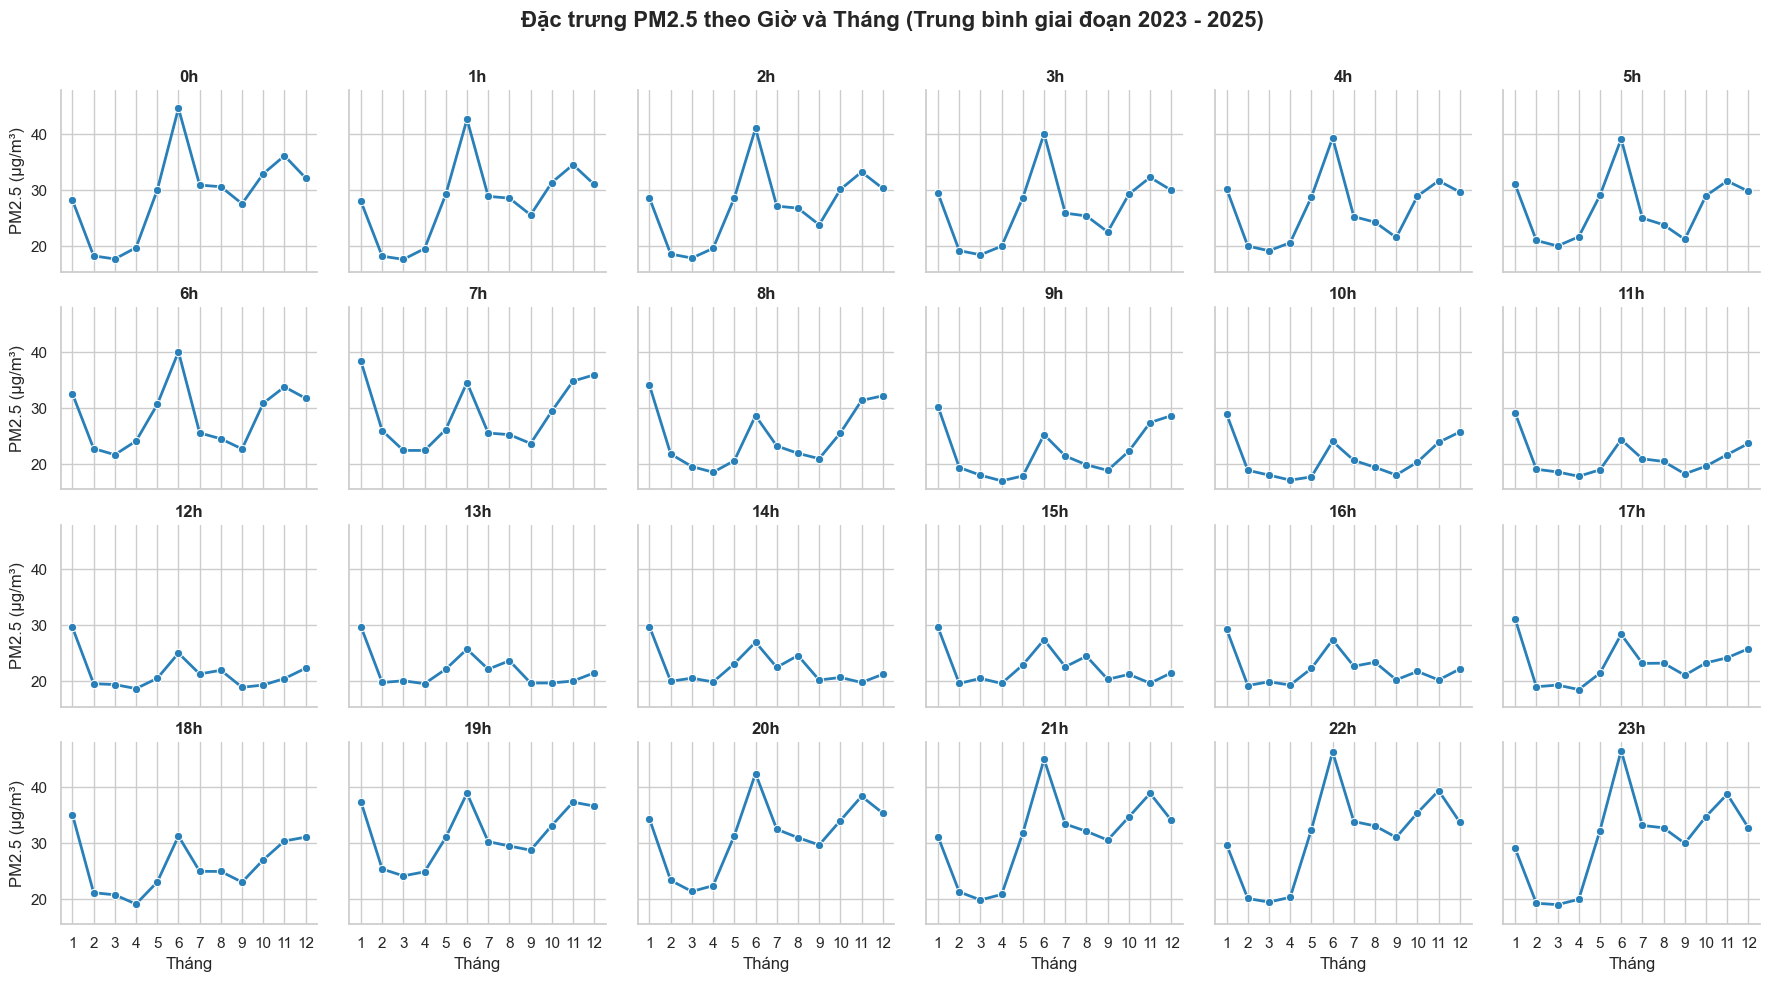

In [7]:
df['time'] = pd.to_datetime(df['time'])

# 2. Trích xuất Tháng và Giờ (Không lọc năm để lấy trung bình tất cả các năm)
df['Month'] = df['time'].dt.month
df['Hour'] = df['time'].dt.hour

# 3. Tính trung bình PM2.5 theo từng Tháng và từng Giờ (Gộp tất cả các năm lại)
# Khi bạn không groupby theo 'Year', các tháng giống nhau của các năm khác nhau 
# sẽ tự động được cộng lại và chia trung bình.
hourly_monthly_avg = df.groupby(['Hour', 'Month'])['PM2.5'].mean().reset_index()

# 4. Vẽ 24 biểu đồ nhỏ (FacetGrid)
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(hourly_monthly_avg, col="Hour", col_wrap=6, height=2.5, aspect=1.2, sharey=True)

# Vẽ đường nối các tháng (Màu xanh dương đậm cho chuyên nghiệp hơn)
g.map(sns.lineplot, "Month", "PM2.5", marker="o", color="#2980b9", linewidth=2)

# Tinh chỉnh giao diện
g.set_axis_labels("Tháng", "PM2.5 (µg/m³)")
g.set_titles("{col_name}h", fontweight='bold')
g.set(xticks=range(1, 13)) # Hiện từ tháng 1 đến tháng 12

# Thêm tiêu đề tổng thể
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Đặc trưng PM2.5 theo Giờ và Tháng (Trung bình giai đoạn 2023 - 2025)', 
               fontsize=16, fontweight='bold')

plt.savefig('xu_huong_pm25_tong_the.png')
plt.show()